# 01 · Exploratory Data Analysis

**LAD-FLEX showcase — datacenter task-level energy flexibility.**

This notebook explores the workload trace that drives the whole study before any
algorithm is applied. The data is a 100,000-task slice of a sorted GPU-cluster
trace, covering
roughly **1970-01-26 → 1970-02-08**. All subsequent analysis focuses on the
representative **sample week 1970-02-01 → 1970-02-07**.

Each row is a computing task with a planned power draw (`plan_power`, W), a
runtime (`runtime_i`, s), and a **wait time** (`wait_time`, s) — the latency the
task tolerated before starting. That tolerated latency is exactly what makes a
task *deferrable*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lad_flex import get_timeline, fast_power_energy_series
import os

sns.set_theme(style="whitegrid")
os.makedirs("outputs", exist_ok=True)

df = pd.read_csv("data/df_tasks_sample.csv", parse_dates=["start_time", "end_time"])
df["t_request"] = df["start_time"] - pd.to_timedelta(df["wait_time"], unit="s")
df.head()

,task_name,start_time,end_time,plan_gpu,plan_mem,gpu_type,plan_cpu,wait_time,runtime_i,plan_power,t_request
0,tensorflow,1970-01-29 16:42:18,1970-01-29 16:45:23,50.0,29.296875,T4,600.0,3.0,182.0,50.0,1970-01-29 16:42:15
1,tensorflow,1970-01-29 16:42:26,1970-01-29 16:43:30,100.0,29.296875,T4,600.0,3.0,61.0,100.0,1970-01-29 16:42:23
2,tensorflow,1970-01-29 16:42:31,1970-01-29 16:51:56,25.0,29.296875,MISC,100.0,47.0,518.0,25.0,1970-01-29 16:41:44
3,PyTorchWorker,1970-01-29 16:42:33,1970-01-29 16:56:22,200.0,4.882812,MISC,300.0,15.0,814.0,200.0,1970-01-29 16:42:18
4,tensorflow,1970-01-29 16:42:33,1970-01-29 16:58:02,25.0,29.296875,MISC,100.0,402.0,527.0,25.0,1970-01-29 16:35:51


## Dataset overview

In [2]:
print("rows, cols:", df.shape)
print("time span:", df["start_time"].min(), "->", df["end_time"].max())
print("\nmissing values per column:")
print(df.isna().sum())
df.describe().T

rows, cols: (100000, 11)
time span: 1970-01-29 16:42:18 -> 1970-02-13 13:33:31

missing values per column:
task_name     0
start_time    0
end_time      0
plan_gpu      0
plan_mem      0
gpu_type      0
plan_cpu      0
wait_time     0
runtime_i     0
plan_power    0
t_request     0
dtype: int64


,count,mean,min,25%,50%,75%,max,std
start_time,100000,1970-02-03 14:31:02.720480,1970-01-29 16:42:18,1970-02-01 09:57:34,1970-02-03 14:08:09,1970-02-05 22:05:52.500000,1970-02-08 09:40:59,NaN
end_time,100000,1970-02-03 16:04:03.689750,1970-01-29 16:43:30,1970-02-01 11:52:49.250000,1970-02-03 15:39:35,1970-02-05 23:32:52.500000,1970-02-13 13:33:31,NaN
plan_gpu,100000.0,70.62817,1.0,25.0,100.0,100.0,800.0,62.142826
plan_mem,100000.0,29.783627,0.976562,29.296875,29.296875,29.296875,300.0,16.669426
plan_cpu,100000.0,710.4678,5.0,600.0,600.0,600.0,9000.0,482.031515
wait_time,100000.0,540.11529,1.0,4.0,9.0,14.0,299037.0,5729.771469
runtime_i,100000.0,4812.160832,0.0,103.0,473.0,3698.0,626371.0,15615.347493
plan_power,100000.0,70.62817,1.0,25.0,100.0,100.0,800.0,62.142826
t_request,100000,1970-02-03 14:22:02.605190,1970-01-26 07:23:38,1970-02-01 09:57:16.250000,1970-02-03 13:31:03.500000,1970-02-05 21:56:59.500000,1970-02-08 09:40:48,NaN


## Distributions: duration, latency, per-task power

Log-scaled counts because the workload is heavy-tailed.

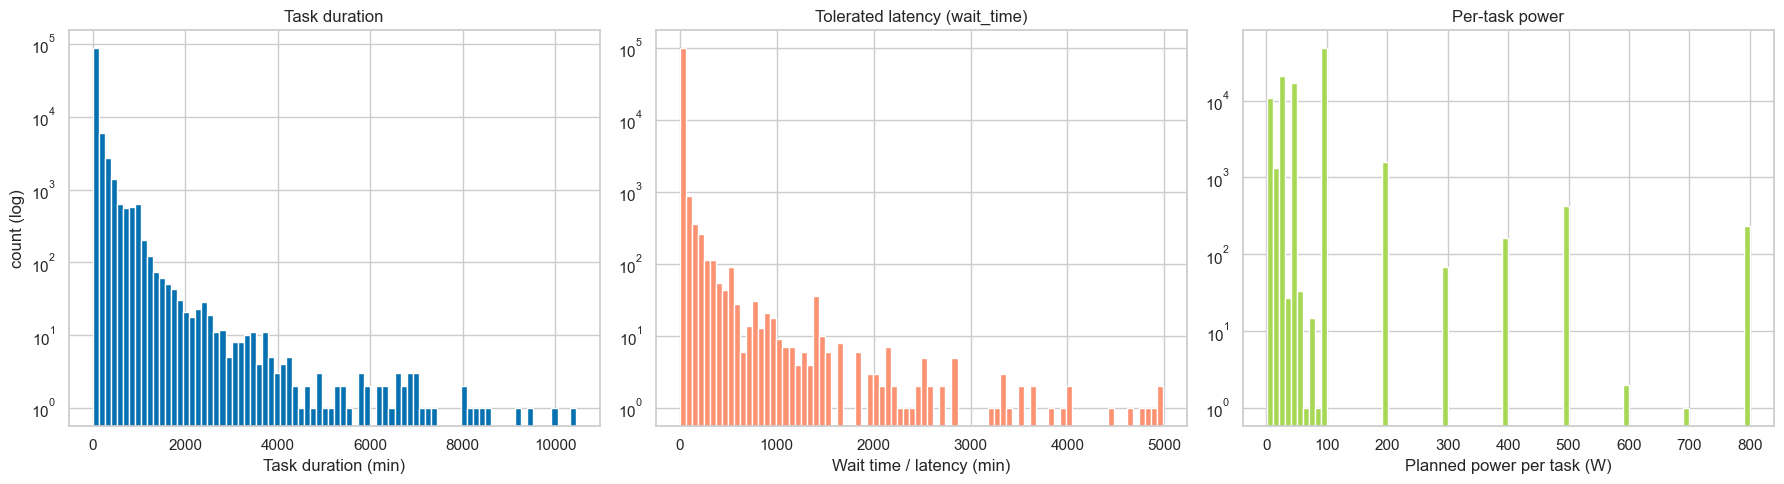

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(df["runtime_i"] / 60, bins=80, color="#0571B0")
axes[0].set_yscale("log"); axes[0].set_xlabel("Task duration (min)")
axes[0].set_ylabel("count (log)"); axes[0].set_title("Task duration")

axes[1].hist(df["wait_time"] / 60, bins=80, color="#FC9272")
axes[1].set_yscale("log"); axes[1].set_xlabel("Wait time / latency (min)")
axes[1].set_title("Tolerated latency (wait_time)")

axes[2].hist(df["plan_power"], bins=80, color="#A6D854")
axes[2].set_yscale("log"); axes[2].set_xlabel("Planned power per task (W)")
axes[2].set_title("Per-task power")
plt.tight_layout(); plt.savefig("outputs/eda_distributions.png", dpi=150); plt.show()

## Workload composition

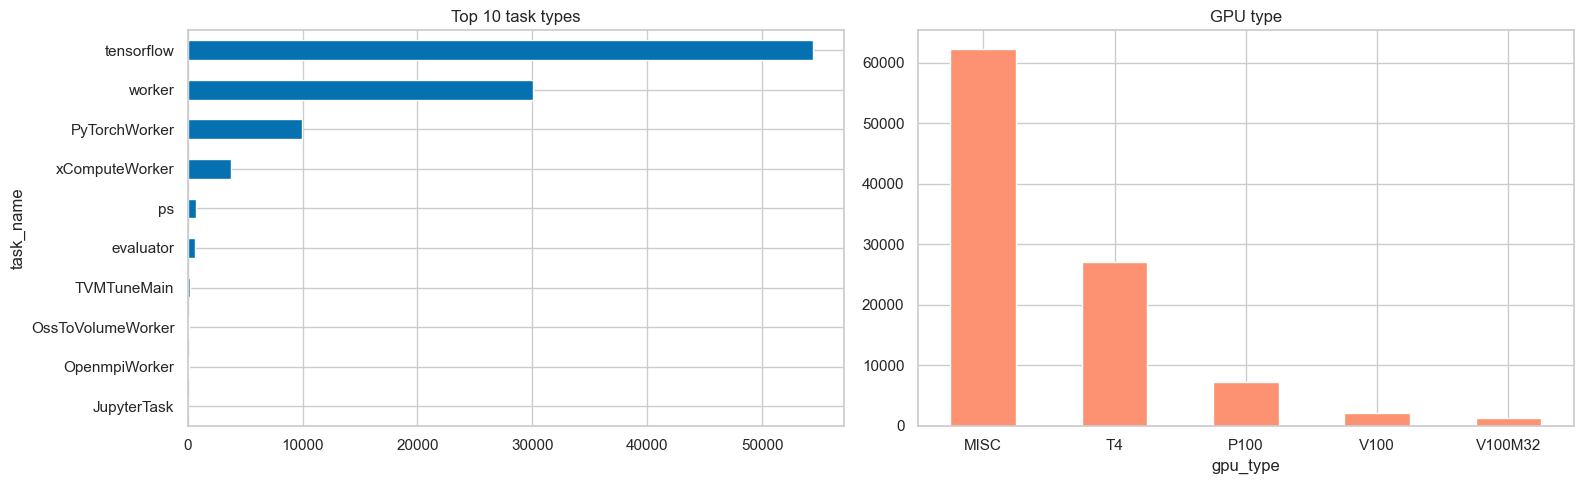

,count,mean,std,min,25%,50%,75%,max
plan_gpu,100000.0,70.628170,62.142826,1.000000,25.000000,100.000000,100.000000,800.0
plan_cpu,100000.0,710.467800,482.031515,5.000000,600.000000,600.000000,600.000000,9000.0
plan_mem,100000.0,29.783627,16.669426,0.976562,29.296875,29.296875,29.296875,300.0
plan_power,100000.0,70.628170,62.142826,1.000000,25.000000,100.000000,100.000000,800.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df["task_name"].value_counts().head(10).plot.barh(ax=axes[0], color="#0571B0")
axes[0].set_title("Top 10 task types"); axes[0].invert_yaxis()
df["gpu_type"].value_counts().plot.bar(ax=axes[1], color="#FC9272")
axes[1].set_title("GPU type"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig("outputs/eda_composition.png", dpi=150); plt.show()

df[["plan_gpu", "plan_cpu", "plan_mem", "plan_power"]].describe().T

## Total datacenter load over the sample week

Built with `fast_power_energy_series`, the same routine the deferability analysis uses later:
in every segment between consecutive task start/end breakpoints, power is the sum
of `plan_power` of the active tasks. This is the load curve the flexibility
analysis tries to reshape.

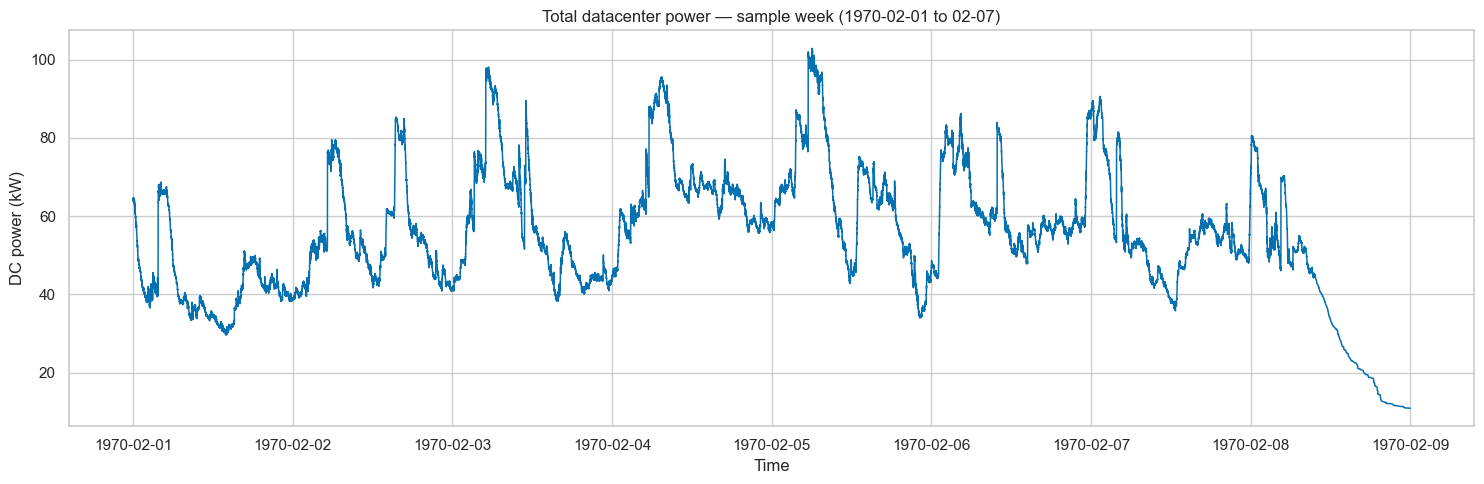

Total DC energy over the sample week: 10577.2 kWh


In [5]:
dc = fast_power_energy_series(df, get_timeline(df))
wk = dc.loc["1970-02-01":"1970-02-08"]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(wk.index, wk["power_kW"], color="#0571B0", lw=1.1)
ax.set_xlabel("Time"); ax.set_ylabel("DC power (kW)")
ax.set_title("Total datacenter power — sample week (1970-02-01 to 02-07)")
plt.tight_layout(); plt.savefig("outputs/eda_dc_power_week.png", dpi=150); plt.show()

print("Total DC energy over the sample week: %.1f kWh" % wk["energy_kWh"].sum())

## How much load is latency-tolerant?

For a range of latency thresholds, what share of tasks — and of energy — has a
`wait_time` above the threshold? This is the upper bound on what LAD-FLEX could
ever defer.

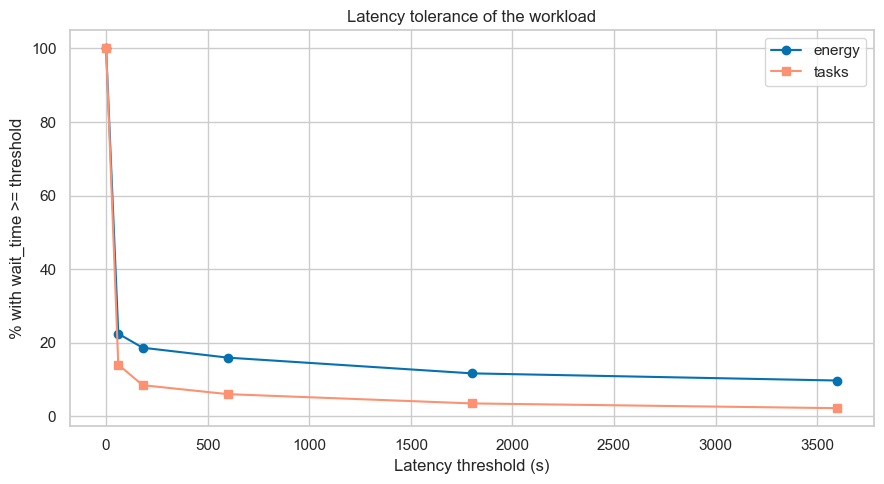

,latency_thr_s,tasks_pct,energy_pct
0,0,100.0,100.0
1,60,14.1,22.5
2,180,8.5,18.7
3,600,6.0,16.0
4,1800,3.5,11.7
5,3600,2.2,9.8


In [6]:
thresholds = [0, 60, 180, 600, 1800, 3600]
total_energy = (df["plan_power"] * df["runtime_i"]).sum()
rows = []
for thr in thresholds:
    mask = df["wait_time"] >= thr
    rows.append({
        "latency_thr_s": thr,
        "tasks_pct": 100 * mask.mean(),
        "energy_pct": 100 * (df.loc[mask, "plan_power"] * df.loc[mask, "runtime_i"]).sum() / total_energy,
    })
lat = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lat["latency_thr_s"], lat["energy_pct"], "-o", color="#0571B0", label="energy")
ax.plot(lat["latency_thr_s"], lat["tasks_pct"], "-s", color="#FC9272", label="tasks")
ax.set_xlabel("Latency threshold (s)"); ax.set_ylabel("% with wait_time >= threshold")
ax.set_title("Latency tolerance of the workload"); ax.legend()
plt.tight_layout(); plt.savefig("outputs/eda_latency_tolerance.png", dpi=150); plt.show()
lat.round(1)

## Which workloads dominate the load?

Energy per task (`plan_power × runtime_i`) aggregated by task type and GPU type.
A few task types carry most of the energy — and therefore most of the deferral
potential.

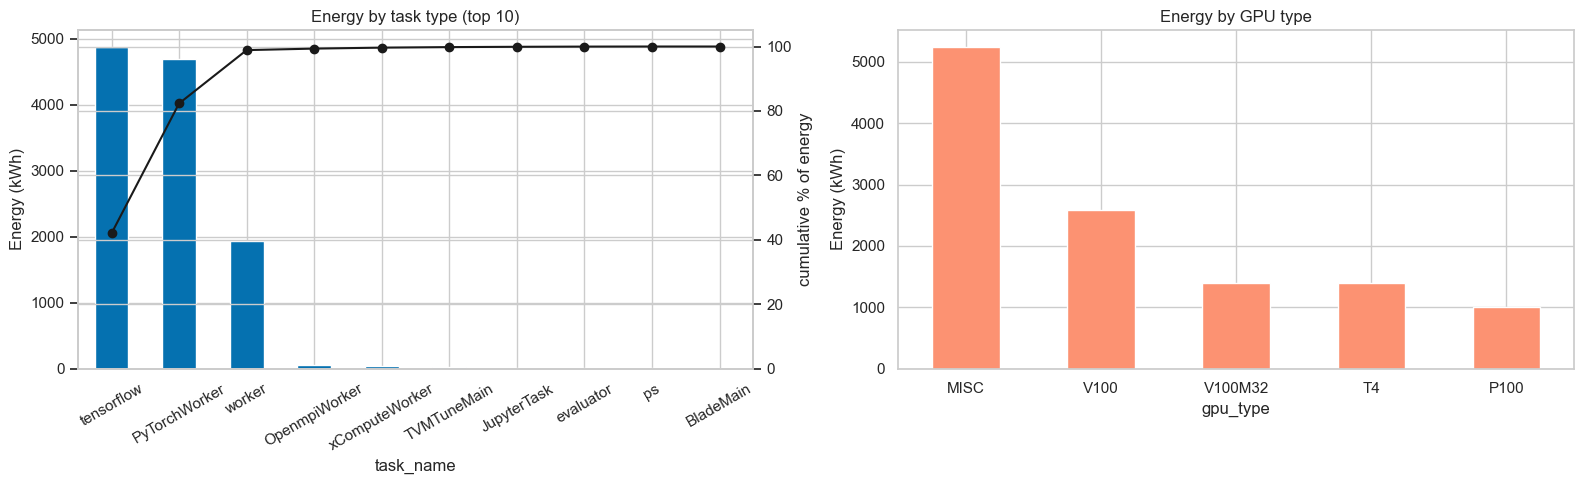

Top task type 'tensorflow' accounts for 42% of total energy


In [7]:
df["task_energy_kWh"] = df["plan_power"] * df["runtime_i"] / 1000 / 3600  # W·s -> kWh
by_task = df.groupby("task_name")["task_energy_kWh"].sum().sort_values(ascending=False)
by_gpu = df.groupby("gpu_type")["task_energy_kWh"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
by_task.head(10).plot.bar(ax=axes[0], color="#0571B0")
axes[0].set_title("Energy by task type (top 10)"); axes[0].set_ylabel("Energy (kWh)")
axes[0].tick_params(axis="x", rotation=30)
cum = by_task.cumsum() / by_task.sum() * 100
ax2 = axes[0].twinx()
ax2.plot(range(len(by_task.head(10))), cum.head(10).values, "k-o", lw=1.5)
ax2.set_ylim(0, 105); ax2.set_ylabel("cumulative % of energy")

by_gpu.plot.bar(ax=axes[1], color="#FC9272")
axes[1].set_title("Energy by GPU type"); axes[1].set_ylabel("Energy (kWh)")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig("outputs/eda_workload_pareto.png", dpi=150); plt.show()

print("Top task type '%s' accounts for %.0f%% of total energy" %
      (by_task.index[0], 100 * by_task.iloc[0] / by_task.sum()))

## When is the datacenter busy?

Mean DC power by day-of-week × hour-of-day (hourly-resampled from the load curve).
This diurnal structure is exactly what flexibility windows can exploit.

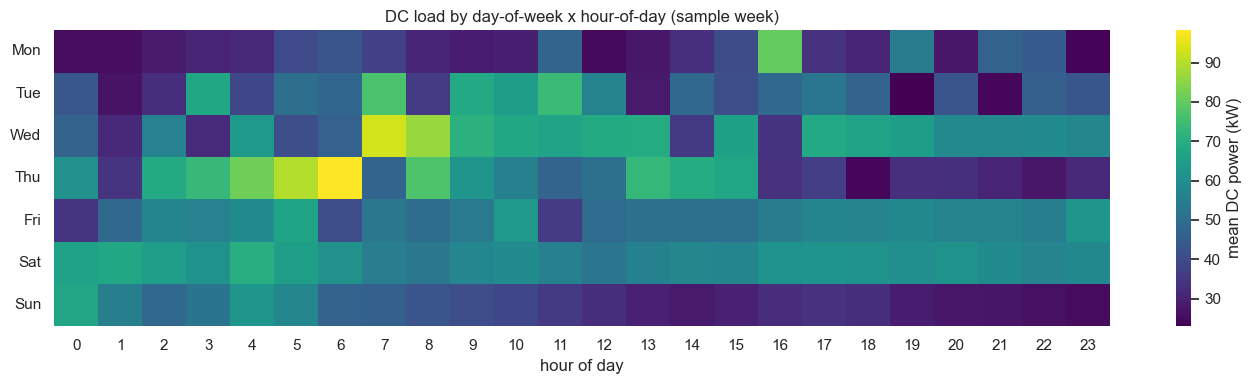

In [8]:
hourly = dc["power_kW"].resample("1h").mean().to_frame("power_kW")
hourly["dow"] = hourly.index.dayofweek
hourly["hour"] = hourly.index.hour
mat = hourly.pivot_table(index="dow", columns="hour", values="power_kW", aggfunc="mean")

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(mat, cmap="viridis", ax=ax, cbar_kws={"label": "mean DC power (kW)"})
day_lbls = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ax.set_yticklabels([day_lbls[d] for d in mat.index], rotation=0)
ax.set_xlabel("hour of day"); ax.set_ylabel("")
ax.set_title("DC load by day-of-week x hour-of-day (sample week)")
plt.tight_layout(); plt.savefig("outputs/eda_load_heatmap.png", dpi=150); plt.show()

## Takeaways

- The workload is **heavy-tailed**: most tasks are short and low-power, a few are
  very long / power-hungry.
- A large fraction of tasks tolerate non-trivial latency, so there is real
  **deferrable energy** to exploit.
- The DC load curve has clear daily structure — flexibility windows can be placed
  where deferral is most valuable.

Next: **`02_lad_flex_method.ipynb`** defines the LAD-FLEX algorithm and runs it
across the three grid-service scenarios.